# ExKMC synthetic blobs experiment

This notebook runs the requested ExKMC Tree experiment on synthetic blobs.

It includes a small compatibility patch so ExKMC works with the current scikit-learn API and the pure-Python splitter fallback in this environment.

In [1]:
import os

# Set before importing sklearn to reduce a known MKL warning on Windows.
os.environ.setdefault("OMP_NUM_THREADS", "1")

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans as SKKMeans
from sklearn.datasets import make_blobs

import ExKMC.Tree as exkmc_tree_module
from ExKMC.splitters import py_cut_finder

In [2]:
def _kmeans_compat(*args, **kwargs):
    kwargs.pop("n_jobs", None)
    return SKKMeans(*args, **kwargs)

# Patch ExKMC references for compatibility with the current environment.
exkmc_tree_module.KMeans = _kmeans_compat
exkmc_tree_module.get_min_mistakes_cut = py_cut_finder.get_min_mistakes_cut
exkmc_tree_module.get_min_surrogate_cut = py_cut_finder.get_min_surrogate_cut
Tree = exkmc_tree_module.Tree

print("ExKMC compatibility patch applied.")

ExKMC compatibility patch applied.


In [3]:
# Create dataset
n = 100
d = 10
k = 3
X, _ = make_blobs(n_samples=n, n_features=d, centers=k, cluster_std=3.0, random_state=42)

# Initialize tree with up to 6 leaves, predicting 3 clusters
tree = Tree(k=k, max_leaves=2 * k, random_state=42)

# Construct the tree, and return cluster labels
prediction = tree.fit_predict(X)

print("X shape:", X.shape)
print("prediction shape:", prediction.shape)
print("predicted clusters:", np.unique(prediction))

X shape: (100, 10)
prediction shape: (100,)
predicted clusters: [0. 1. 2.]


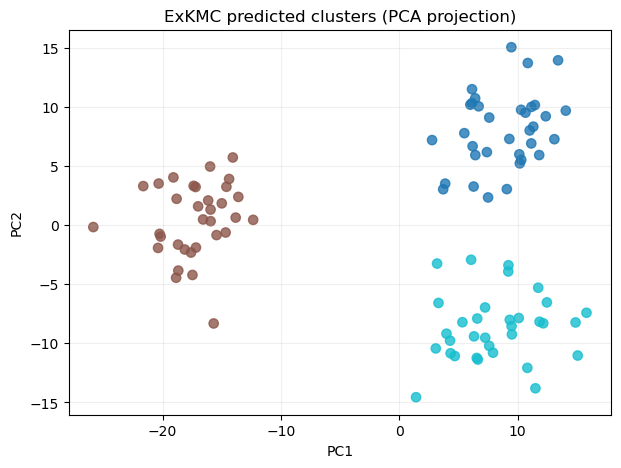

In [4]:
# Quick 2D view of the discovered clusters
from sklearn.decomposition import PCA

X_2d = PCA(n_components=2, random_state=42).fit_transform(X)
plt.figure(figsize=(7, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=prediction.astype(int), cmap="tab10", s=45, alpha=0.8)
plt.title("ExKMC predicted clusters (PCA projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.2)
plt.show()

In [5]:
# Quick environment check for plot rendering support
from shutil import which

dot_path = which("dot")
print("OMP_NUM_THREADS =", os.environ.get("OMP_NUM_THREADS", "<unset>"))
if dot_path:
    print(f"Graphviz dot found on PATH: {dot_path}")
    print("tree.plot() should be able to render PNG output.")
else:
    print("Graphviz dot not found on PATH.")
    print("tree.plot() can still train ExKMC, but .gv.png rendering will fail.")
    print("Install Graphviz and add dot to PATH to enable rendering.")

OMP_NUM_THREADS = 1
Graphviz dot not found on PATH.
tree.plot() can still train ExKMC, but .gv.png rendering will fail.
Install Graphviz and add dot to PATH to enable rendering.


In [6]:
# Save tree plot output.
# ExKMC expects Graphviz system binaries (dot) to be available on PATH.
repo_root = Path.cwd()
if not (repo_root / "scripts").exists() and (repo_root.parent / "scripts").exists():
    repo_root = repo_root.parent
elif not (repo_root / "scripts").exists() and (repo_root.parent.parent / "scripts").exists():
    repo_root = repo_root.parent.parent

out_dir = repo_root / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)
plot_base = out_dir / "exkmc_blobs_tree"

try:
    tree.plot(str(plot_base))
    print("Tree plot generated near:", str(plot_base) + ".gv.png")
except Exception as e:
    print("tree.plot could not render in this environment:", type(e).__name__, e)
    print("Training and predictions are still complete.")
    print("Install Graphviz system binaries and add dot to PATH to enable rendering.")

digraph ClusteringTree {
n_0 [label="1 <= 0.156
samples=\100"];
n_1 [label="1
samples=\33
mistakes=\0"];
n_2 [label="9 <= -1.909
samples=\67"];
n_3 [label="2
samples=\31
mistakes=\0"];
n_4 [label="3 <= -4.621
samples=\36"];
n_5 [label="2
samples=\2
mistakes=\0"];
n_6 [label="0
samples=\34
mistakes=\0"];
n_0 -> n_1;
n_0 -> n_2;
n_2 -> n_3;
n_2 -> n_4;
n_4 -> n_5;
n_4 -> n_6;
}
tree.plot could not render in this environment: ExecutableNotFound failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH
Training and predictions are still complete.
Install Graphviz system binaries and add dot to PATH to enable rendering.


## ECG5000 extension (real-world UCR dataset)

This section reuses the same workflow style on `ECG5000`:

1. Load real UCR data from repository files.
2. Select `k` with unsupervised quality + stability.
3. Fit ExKMC and KMeans on identical inputs.
4. Compare internal and post-hoc external metrics.
5. Save ExKMC tree output under `outputs/`.

In [7]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    accuracy_score,
)

root_candidates = [
    (Path('..') / '..' / 'data' / 'UCRArchive_2018').resolve(),
    (Path('..') / '..' / 'data' / 'UCRArchive_2018' / 'UCRArchive_2018').resolve(),
]
UCR_ROOT = next((p for p in root_candidates if p.exists()), root_candidates[0])

dataset_name = 'ECG5000'
train_path = UCR_ROOT / dataset_name / f'{dataset_name}_TRAIN.tsv'
test_path = UCR_ROOT / dataset_name / f'{dataset_name}_TEST.tsv'

if not train_path.exists() or not test_path.exists():
    raise FileNotFoundError(
        f'Could not find ECG5000 files. Checked: {train_path} and {test_path}'
    )

train_df = pd.read_csv(train_path, sep='\t', header=None)
test_df = pd.read_csv(test_path, sep='\t', header=None)
ecg_df = pd.concat([train_df, test_df], ignore_index=True)

y_ecg5000 = ecg_df.iloc[:, 0].to_numpy()
X_ecg5000 = ecg_df.iloc[:, 1:].to_numpy(dtype=float)
X_ecg5000_std = StandardScaler().fit_transform(X_ecg5000)

print('UCR root:', UCR_ROOT)
print('Dataset:', dataset_name)
print('Samples x TimePoints:', X_ecg5000.shape)
print('Classes:', np.unique(y_ecg5000))
print('Class distribution:')
display(pd.Series(y_ecg5000).value_counts().sort_index().to_frame('count'))

UCR root: D:\repositories\personal\xai-spatio-temporal\data\UCRArchive_2018
Dataset: ECG5000
Samples x TimePoints: (5000, 140)
Classes: [1 2 3 4 5]
Class distribution:


,count
1,2919
2,1767
3,96
4,194
5,24


In [8]:
# Unsupervised k selection (silhouette + seed stability)
k_values = list(range(2, 9))
seed_list = [0, 1, 2, 3, 4]

rows = []
for k in k_values:
    labels_by_seed = []
    sil_by_seed = []
    ch_by_seed = []
    db_by_seed = []

    for seed in seed_list:
        km = SKKMeans(n_clusters=k, random_state=seed, n_init=30)
        labels = km.fit_predict(X_ecg5000_std)
        labels_by_seed.append(labels)
        sil_by_seed.append(float(silhouette_score(X_ecg5000_std, labels)))
        ch_by_seed.append(float(calinski_harabasz_score(X_ecg5000_std, labels)))
        db_by_seed.append(float(davies_bouldin_score(X_ecg5000_std, labels)))

    pairwise_ari = []
    for i in range(len(labels_by_seed)):
        for j in range(i + 1, len(labels_by_seed)):
            pairwise_ari.append(adjusted_rand_score(labels_by_seed[i], labels_by_seed[j]))

    stability_ari = float(np.mean(pairwise_ari)) if pairwise_ari else 1.0

    rows.append(
        {
            'k': int(k),
            'silhouette': float(np.mean(sil_by_seed)),
            'silhouette_std': float(np.std(sil_by_seed, ddof=0)),
            'calinski_harabasz': float(np.mean(ch_by_seed)),
            'davies_bouldin': float(np.mean(db_by_seed)),
            'stability_ari': stability_ari,
        }
    )

ecg5000_k_selection_df = pd.DataFrame(rows)

# Keep the same ranking spirit as your KMeans notebooks: quality + stability, mild bias for smaller k
k_penalty = 0.10
min_k = int(ecg5000_k_selection_df['k'].min())
ecg5000_k_selection_df['composite_score'] = (
    ecg5000_k_selection_df['silhouette']
    + 0.5 * ecg5000_k_selection_df['stability_ari']
    - k_penalty * (ecg5000_k_selection_df['k'] - min_k)
)

ecg5000_k_selection_df = ecg5000_k_selection_df.sort_values(
    ['composite_score', 'silhouette', 'stability_ari', 'k'],
    ascending=[False, False, False, True],
).reset_index(drop=True)

best_k_ecg5000 = int(ecg5000_k_selection_df.iloc[0]['k'])

print('ECG5000 unsupervised k-selection table:')
display(ecg5000_k_selection_df)
print('Chosen k (unsupervised):', best_k_ecg5000)

ECG5000 unsupervised k-selection table:


,k,silhouette,silhouette_std,calinski_harabasz,davies_bouldin,stability_ari,composite_score
0,2,0.332102,0.000000,1919.618060,1.395935,1.000000,0.832102
1,3,0.355244,0.000000,1610.902981,1.264655,1.000000,0.755244
2,4,0.370119,0.000027,1456.456320,1.221757,0.999559,0.669899
3,5,0.250459,0.000080,1317.715768,1.432389,0.999123,0.450021
4,6,0.186890,0.000268,1189.356365,1.613549,0.995093,0.284436
5,7,0.193289,0.000052,1098.012988,1.609132,0.998388,0.192483
6,8,0.190661,0.000124,1035.004698,1.582172,0.994251,0.087786


Chosen k (unsupervised): 2


In [9]:
# Fit KMeans and ExKMC on ECG5000 with the same selected k
kmeans_ecg5000 = SKKMeans(n_clusters=best_k_ecg5000, random_state=42, n_init=50)
labels_kmeans_ecg5000 = kmeans_ecg5000.fit_predict(X_ecg5000_std)

tree_ecg5000 = Tree(k=best_k_ecg5000, max_leaves=2 * best_k_ecg5000, random_state=42)
labels_exkmc_ecg5000 = tree_ecg5000.fit_predict(X_ecg5000_std)


def _majority_label_mapping(y_ref, clusters):
    mapping = {}
    for c in np.unique(clusters):
        mapping[c] = pd.Series(y_ref[clusters == c]).mode().iloc[0]
    return mapping


def _mapped_predictions(clusters, mapping):
    return np.array([mapping[c] for c in clusters])


summary_rows = []
for model_name, labels in [
    ('KMeans', labels_kmeans_ecg5000),
    ('ExKMC', labels_exkmc_ecg5000),
]:
    mapping = _majority_label_mapping(y_ecg5000, labels)
    pred_mapped = _mapped_predictions(labels, mapping)

    summary_rows.append(
        {
            'model': model_name,
            'k': int(best_k_ecg5000),
            'silhouette': float(silhouette_score(X_ecg5000_std, labels)),
            'calinski_harabasz': float(calinski_harabasz_score(X_ecg5000_std, labels)),
            'davies_bouldin': float(davies_bouldin_score(X_ecg5000_std, labels)),
            'ari': float(adjusted_rand_score(y_ecg5000, labels)),
            'nmi': float(normalized_mutual_info_score(y_ecg5000, labels)),
            'mapped_accuracy': float(accuracy_score(y_ecg5000, pred_mapped)),
        }
    )

ecg5000_model_summary_df = pd.DataFrame(summary_rows).sort_values('model').reset_index(drop=True)
print('ECG5000 model comparison (same k, same standardized inputs):')
display(ecg5000_model_summary_df)

ECG5000 model comparison (same k, same standardized inputs):


,model,k,silhouette,calinski_harabasz,davies_bouldin,ari,nmi,mapped_accuracy
0,ExKMC,2,0.326155,1857.577898,1.416256,0.765169,0.650519,0.9010
1,KMeans,2,0.332102,1919.618060,1.395935,0.772532,0.648550,0.9032


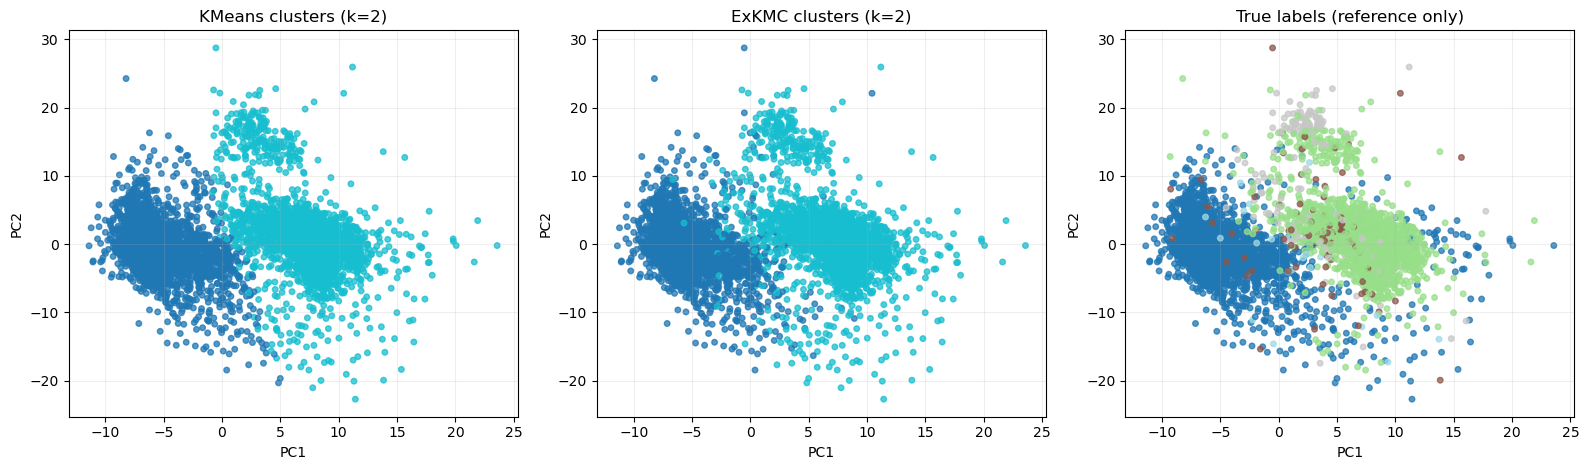

In [10]:
# PCA view of ECG5000 clustering outputs
from sklearn.decomposition import PCA

X_ecg5000_2d = PCA(n_components=2, random_state=42).fit_transform(X_ecg5000_std)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

axes[0].scatter(X_ecg5000_2d[:, 0], X_ecg5000_2d[:, 1], c=labels_kmeans_ecg5000.astype(int), cmap='tab10', s=16, alpha=0.75)
axes[0].set_title(f'KMeans clusters (k={best_k_ecg5000})')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].grid(alpha=0.2)

axes[1].scatter(X_ecg5000_2d[:, 0], X_ecg5000_2d[:, 1], c=labels_exkmc_ecg5000.astype(int), cmap='tab10', s=16, alpha=0.75)
axes[1].set_title(f'ExKMC clusters (k={best_k_ecg5000})')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].grid(alpha=0.2)

axes[2].scatter(X_ecg5000_2d[:, 0], X_ecg5000_2d[:, 1], c=y_ecg5000.astype(int), cmap='tab20', s=16, alpha=0.75)
axes[2].set_title('True labels (reference only)')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [11]:
# Save ECG5000 ExKMC tree output
repo_root = Path.cwd()
if not (repo_root / 'scripts').exists() and (repo_root.parent / 'scripts').exists():
    repo_root = repo_root.parent
elif not (repo_root / 'scripts').exists() and (repo_root.parent.parent / 'scripts').exists():
    repo_root = repo_root.parent.parent

out_dir = repo_root / 'outputs'
out_dir.mkdir(parents=True, exist_ok=True)
plot_base = out_dir / 'exkmc_ecg5000_tree'

try:
    tree_ecg5000.plot(str(plot_base))
    print('ECG5000 tree plot generated near:', str(plot_base) + '.gv.png')
except Exception as e:
    print('tree.plot could not render in this environment:', type(e).__name__, e)
    print('Training and predictions are still complete.')
    print('Install Graphviz system binaries and add dot to PATH to enable rendering.')

digraph ClusteringTree {
n_0 [label="105 <= -0.181
samples=\5000"];
n_1 [label="34 <= -0.332
samples=\2319"];
n_2 [label="132 <= -0.679
samples=\2681"];
n_3 [label="0
samples=\155
mistakes=\13"];
n_4 [label="1
samples=\2164
mistakes=\78"];
n_5 [label="1
samples=\24
mistakes=\3"];
n_6 [label="0
samples=\2657
mistakes=\27"];
n_0 -> n_1;
n_0 -> n_2;
n_1 -> n_3;
n_1 -> n_4;
n_2 -> n_5;
n_2 -> n_6;
}
tree.plot could not render in this environment: ExecutableNotFound failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH
Training and predictions are still complete.
Install Graphviz system binaries and add dot to PATH to enable rendering.
